# **Z-Score "Estatística Aplicada à Geotecnia e Erosão"**


## 1. Introdução: Por que Amostragem?


*A* **amostragem** é o processo de selecionar uma parte representativa de uma população para inferir características do todo. No estudo dos processos erosivos, a amostragem é essencial devido a:
**Economia e Tempo:** É inviável realizar ensaios geotécnicos em cada metro quadrado.
**Operacionalidade:** Permite o controle rigoroso da coleta de parâmetros como coesão e ângulo de atrito em pontos estratégicos.
**Confiabilidade:** Quando bem planejada, garante que os dados de satélite coincidam com a realidade do solo.

## 2. Técnicas de Amostragem aplicadas às Geotecnologias

**Para correlacionar imagens de satélite com parâmetros físicos**, alguns pesuisadores utilizaram diferentes métodos:
**Amostragem Estratificada Proporcional:**  que consiste em dividir a bacia em subgrupos homogêneos (estratos) baseados em mapas de solo ou declividade.
Isso gera resultados mais precisos que uma amostra aleatória simples ao lidar com terrenos heterogêneos.
**Amostragem Sistemática:** Utilizada para validar modelos de erosão (como o RUSLE) criando uma grade regular de pontos de controle sobre a imagem de satélite.
**Amostragem por Julgamento** (Não Aleatória): Escolha de pontos "típicos" ou críticos, como encostas com histórico conhecido de deslizamento ou voçorocas.

## 3. Dimensionamento da Amostra Geotécnica

Para garantir que sua previsão de erosão seja estatisticamente válida, o tamanho da amostra (n) deve ser calculado considerando um erro tolerável (E):

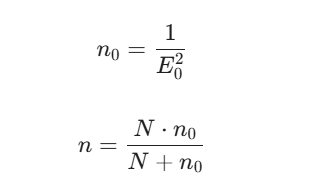

Onde $N$ é o número total de pontos possíveis na área de estudo.

## 4.Simulação e Teste de Normalidade



Antes de qualquer análise, devemos verificar se os dados seguem uma Distribuição Normal. Isso é fundamental para garantir a Confiabilidade dos Dados.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuração visual
sns.set_theme(style="whitegrid")

# 1. Simulação de Dados de Campo (ex: Coesão em kPa na Bacia do Recôncavo)
# Supomos 150 amostras coletadas via plano de amostragem estratificada
np.random.seed(42)
media_real = 22.5  # kPa
desvio_real = 6.2
coesao_solo = np.random.normal(media_real, desvio_real, 150)

# Criando um DataFrame
df = pd.DataFrame({'Coesao_kPa': coesao_solo})

# 2. Visualização: Histogramas e Boxplot (Identificação de Outliers/Erros)
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Coesao_kPa'], kde=True, color='green', ax=axs[0])
axs[0].set_title('Distribuição da Coesão do Solo')

sns.boxplot(x=df['Coesao_kPa'], color='lightgreen', ax=axs[1])
axs[1].set_title('Boxplot: Identificação de Outliers')
plt.show()

# 3. Teste de Shapiro-Wilk (Validação Estatística)
stat, p_valor = stats.shapiro(df['Coesao_kPa'])
print(f'P-valor: {p_valor:.4f}')

if p_valor > 0.05:
    print("Conclusão: Os dados seguem uma Distribuição Normal.")
else:
    print("Conclusão: Os dados NÃO seguem uma Distribuição Normal.")

## 5. Validação de Parâmetros de Erodibilidade via Amostragem
Alguns trabalho que usaram e fizeram validação da erodibilidade via amostragem segue o seguinte link
https://sjar.revistas.csic.es/index.php/sjar/article/view/2046/1536


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURAÇÃO DO PLANO DE AMOSTRAGEM
# Definimos os estratos (tipos de solo) e a quantidade de amostras por tipo
estratos_solo = {
    'Argissolo (Encostas)': 15,
    'Latossolo (Platôs)': 12,
    'Neossolo (Áreas de Erosão)': 10,
    'Gleissolo (Zonas Úmidas)': 8
}

data_list = []

# 2. SIMULAÇÃO DE COLETA DE PARÂMETROS GEOTÉCNICOS
# Simulando a variabilidade da Coesão (c') e Ângulo de Atrito (phi)
np.random.seed(7)

for solo, n_amostras in estratos_solo.items():
    for i in range(n_amostras):
        # Gerando dados com médias diferentes para cada tipo de solo
        if 'Argissolo' in solo:
            coesao = np.random.normal(25, 4) # Média 25 kPa
            atrito = np.random.normal(22, 2)
        elif 'Latossolo' in solo:
            coesao = np.random.normal(15, 3) # Mais arenoso/menos coeso
            atrito = np.random.normal(28, 3)
        else:
            coesao = np.random.normal(10, 5)
            atrito = np.random.normal(18, 4)

        data_list.append({
            'Tipo_Solo': solo,
            'Amostra_ID': f"{solo[:3]}_{i+1}",
            'Coesao_kPa': round(coesao, 2),
            'Angulo_Atrito_Deg': round(atrito, 2)
        })

# Criando o DataFrame
df_reconcavo = pd.DataFrame(data_list)

# 3. ANÁLISE ESTATÍSTICA DESCRITIVA
print("--- Resumo Estatístico por Estrato de Solo ---")
resumo = df_reconcavo.groupby('Tipo_Solo')['Coesao_kPa'].agg(['mean', 'std', 'count']).rename(columns={'mean': 'Média Coesão', 'std': 'Desvio Padrão', 'count': 'Nº Amostras'})
print(resumo)

# 4. VISUALIZAÇÃO PARA PLANEJAMENTO DE EXPERIMENTOS
plt.figure(figsize=(12, 6))

# Boxplot para ver a dispersão e identificar possíveis "Outliers"
sns.boxplot(x='Tipo_Solo', y='Coesao_kPa', data=df_reconcavo, palette='viridis')
sns.stripplot(x='Tipo_Solo', y='Coesao_kPa', data=df_reconcavo, color='black', alpha=0.3)

plt.title('Variabilidade da Coesão Geotécnica por Estrato')
plt.ylabel('Coesão (kPa)')
plt.xlabel('Unidade Amostral (Solo)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. EXPORTAÇÃO
# df_reconcavo.to_csv('amostras_geotecnicas_reconcavo.csv', index=False)

## 6.Integração SIG e Cálculo de Risco


Com a amostra validada, definimos um limiar crítico. Na geotecnia, se a coesão for muito baixa (ex: < 10 kPa), o solo é altamente suscetível à erosão hídrica.
Acesse o link do trabalho https://www.mdpi.com/2073-4441/13/24/3621?utm_source=chatgpt.com

In [ ]:
from scipy.stats import norm

# 1. Parâmetros da Amostra
media_amostral = df['Coesao_kPa'].mean()
desvio_amostral = df['Coesao_kPa'].std()
limiar_critico = 10.0 # Limiar de segurança geotécnica

# 2. Cálculo da Probabilidade de Risco (Área sob a curva)
probabilidade_risco = norm.cdf(limiar_critico, media_amostral, desvio_amostral)
print(f"Risco de Erosão nesta área: {probabilidade_risco*100:.2f}%")

# 3. Visualização da 'Zona de Perigo'
x = np.linspace(media_amostral - 4*desvio_amostral, media_amostral + 4*desvio_amostral, 200)
plt.figure(figsize=(10, 6))
plt.plot(x, norm.pdf(x, media_amostral, desvio_amostral), 'b-', label='Curva Normal Ajustada')
x_risco = np.linspace(media_amostral - 4*desvio_amostral, limiar_critico, 100)
plt.fill_between(x_risco, norm.pdf(x_risco, media_amostral, desvio_amostral), color='red', alpha=0.5, label='Zona de Alto Risco')
plt.title('Identificação Estatística de Áreas Propensas à Erosão')
plt.xlabel('Coesão (kPa)')
plt.legend()
plt.show()

## 7. Mapeamento Espacial (Simulação SIG)
Integração da estatística com a geotecnologia para gerar um mapa de risco.

In [ ]:
from scipy.ndimage import gaussian_filter

# Simulação de grade 50x50 (Pixels de um Satélite/SIG)
mapa_dim = (50, 50)
mapa_risco = gaussian_filter(np.random.rand(*mapa_dim), sigma=2)
mapa_risco_final = (mapa_risco - mapa_risco.min()) / (mapa_risco.max() - mapa_risco.min())

plt.figure(figsize=(8, 7))
plt.imshow(mapa_risco_final, cmap='RdYlGn_r', origin='lower')
plt.colorbar(label='Probabilidade de Erosão')
plt.title('Mapa de Risco de Erosão Geoprocessado')
plt.show()

A análise de variabilidade espacial é importante porque a erosão do solo não ocorre de forma uniforme, variando conforme relevo, tipo de solo e uso da terra. Com técnicas geoestatísticas como **krigagem**, **semivariograma e IDW**, é possível transformar dados pontuais em mapas contínuos, identificando áreas mais críticas. Isso melhora a precisão de modelos como o **RUSLE**, apoia decisões geotécnicas e contribui para o planejamento ambiental e a prevenção de riscos

In [ ]:
# Instalar bibliotecas
!pip install numpy pandas matplotlib scikit-learn pykrige

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging
from scipy.spatial.distance import cdist

# -----------------------------
# 1. GERAR DADOS SIMULADOS
# -----------------------------
np.random.seed(42)

n_points = 30
x = np.random.uniform(0, 100, n_points)
y = np.random.uniform(0, 100, n_points)

# Simulando perda de solo (RUSLE-like)
z = 0.5 * x + 0.3 * y + np.random.normal(0, 10, n_points)

data = pd.DataFrame({'x': x, 'y': y, 'z': z})

# -----------------------------
# 2. SEMIVARIOGRAMA (SIMPLES)
# -----------------------------
def semivariogram(x, y, z, max_dist, n_bins):
    coords = np.column_stack((x, y))
    dist = cdist(coords, coords)
    diff = (z[:, None] - z[None, :])**2 / 2

    bins = np.linspace(0, max_dist, n_bins)
    gamma = []

    for i in range(len(bins)-1):
        mask = (dist >= bins[i]) & (dist < bins[i+1])
        gamma.append(np.mean(diff[mask]))

    return bins[:-1], gamma

distances, gamma = semivariogram(x, y, z, max_dist=100, n_bins=15)

plt.figure()
plt.plot(distances, gamma, 'o-')
plt.title("Semivariograma")
plt.xlabel("Distância")
plt.ylabel("Semivariância")
plt.show()

# -----------------------------
# 3. KRIGAGEM
# -----------------------------
gridx = np.linspace(0, 100, 50)
gridy = np.linspace(0, 100, 50)

OK = OrdinaryKriging(x, y, z,
                     variogram_model='linear',
                     verbose=False)

z_krig, ss = OK.execute('grid', gridx, gridy)

plt.figure()
plt.imshow(z_krig, origin='lower', extent=(0,100,0,100))
plt.scatter(x, y, c=z, edgecolor='k')
plt.title("Mapa por Krigagem")
plt.colorbar(label="Perda de solo")
plt.show()

# -----------------------------
# 4. IDW
# -----------------------------
def idw(x, y, z, xi, yi, power=2):
    dist = np.sqrt((x - xi)**2 + (y - yi)**2)
    weights = 1 / (dist**power + 1e-10)
    return np.sum(weights * z) / np.sum(weights)

grid_idw = np.zeros((50, 50))

for i in range(50):
    for j in range(50):
        grid_idw[i, j] = idw(x, y, z, gridx[i], gridy[j])

plt.figure()
plt.imshow(grid_idw, origin='lower', extent=(0,100,0,100))
plt.scatter(x, y, c=z, edgecolor='k')
plt.title("Mapa por IDW")
plt.colorbar(label="Perda de solo")
plt.show()

## Artigos Relacionados

1. DOI: https://doi.org/10.5424/sjar/20110903-229-10  
1. https://link.springer.com/article/10.1007/s12665-025-12271-8?utm_source=chatgpt.com  
2.   https://www.mdpi.com/1999-4907/15/6/1039?utm_source=chatgpt.com
3.   https://www.sciencedirect.com/science/article/pi
S2095633925000930
4.   https://onlinelibrary.wiley.com/doi/10.1002/esp.70019




